## Exploration

## Dataset Overview
- This section investigates the dataframe (columns, rows) and the class variable before adapting the dataframe

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('default')
import seaborn as sns

df = pd.read_csv("../data/raw/2023-24 RLS Public Use File Feb 19.csv")
print(f"Shape: {df.shape}")
print(f"Rows: {df.shape[0]:,} | Columns: {df.shape[1]}")

Shape: (36908, 654)
Rows: 36,908 | Columns: 654


In [8]:
# data types
print("Data types:")
print(df.dtypes.value_counts())

df.head()

Data types:
float64    543
int64      111
Name: count, dtype: int64


,P_SUID,YEAR_FROM_CODATE,REGION,HAPPY,SATIS_A,SATIS_B,CHNG_A,CHNG_B,CHNG_C,DIVRELPOP,...,REPWT_491,REPWT_492,REPWT_493,REPWT_494,REPWT_495,REPWT_496,REPWT_497,REPWT_498,REPWT_499,REPWT_500
0,10000040,2023,NaN,1,2,2,2,3,2,2,...,8637.197077,3197.889015,6477.569705,5074.236372,0.000000,4227.254255,0.000000,3958.231750,7956.793610,3953.976457
1,10000060,2023,NaN,1,2,1,1,1,1,1,...,0.000000,12887.026798,0.000000,13146.109522,0.000000,9759.575389,8258.191691,9066.092538,6611.317293,0.000000
2,10000140,2024,NaN,2,2,3,3,1,1,1,...,3495.132770,0.000000,0.000000,0.000000,4218.483874,4109.599461,2023.737545,0.000000,4142.783211,0.000000
3,10000150,2023,NaN,3,3,3,2,1,2,3,...,0.000000,5543.688048,17339.292421,4533.605170,12847.018842,7761.160369,6794.489739,0.000000,6840.329912,5372.092714
4,10000160,2023,NaN,3,1,1,3,1,2,1,...,0.000000,2288.029759,3481.582023,6922.944804,2903.262530,0.000000,3124.679185,2674.370394,0.000000,5957.761219


In [15]:
print(df['QB2C'].value_counts())

QB2C
2     23364
1     12761
99      783
Name: count, dtype: int64


In [9]:
#drop 99s from class variable for initial exploration
df_binary = df[df['QB2C'] != 99].copy()
df_binary['QB2C_binary'] = df_binary['QB2C'].map({2: 1, 1: 0})
# 1 = Pro-regulation (worth the cost)
# 0 = Anti-regulation (hurts economy)

## 2. Initial Religion Findings

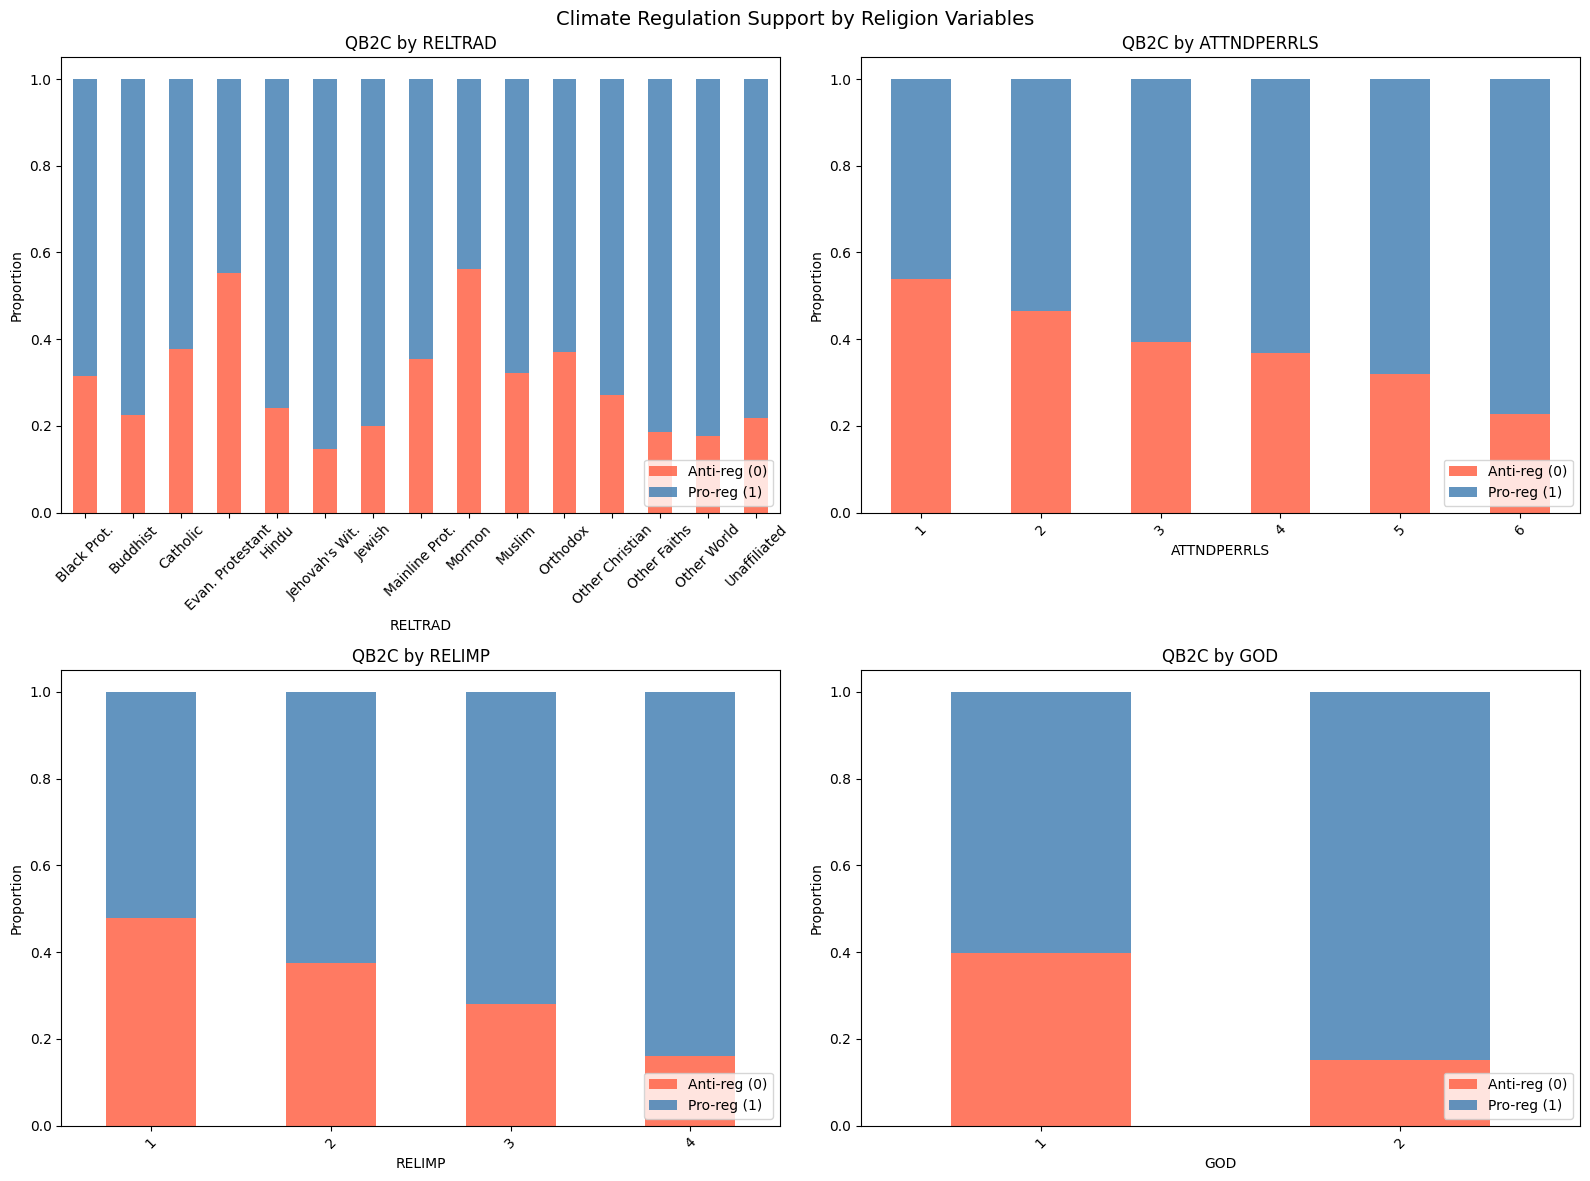

In [10]:
# QB2C vs Religion cross-tabs
rel_plot_vars = ['RELTRAD', 'ATTNDPERRLS', 'RELIMP', 'GOD']
rel_plot_vars = [v for v in rel_plot_vars if v in df_binary.columns]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

reltrad_labels = {
    1100: 'Evan. Protestant', 1200: 'Mainline Prot.', 1300: 'Black Prot.',
    10000: 'Catholic', 20000: 'Mormon', 30000: 'Orthodox',
    40001: "Jehovah's Wit.", 40002: 'Other Christian',
    50000: 'Jewish', 60000: 'Muslim', 70000: 'Buddhist',
    80000: 'Hindu', 90001: 'Other World', 90002: 'Other Faiths',
    100000: 'Unaffiliated'
}

for i, var in enumerate(rel_plot_vars):
    temp = df_binary[~df_binary[var].isin([99, 900000])].copy()
    if var == 'RELTRAD':
        temp[var] = temp[var].map(reltrad_labels)
    ct = pd.crosstab(temp[var], temp['QB2C_binary'], normalize='index')
    ct.columns = ['Anti-reg (0)', 'Pro-reg (1)']
    ct.plot(kind='bar', stacked=True, ax=axes[i],
            color=['tomato', 'steelblue'], alpha=0.85)
    axes[i].set_title(f'QB2C by {var}')
    axes[i].set_ylabel('Proportion')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].legend(loc='lower right')

plt.suptitle('Climate Regulation Support by Religion Variables', fontsize=14)
plt.tight_layout()
plt.savefig('../results/01_QB2C_By_Religion.svg', bbox_inches='tight')
plt.show()

## 3. Initial demographic Findings


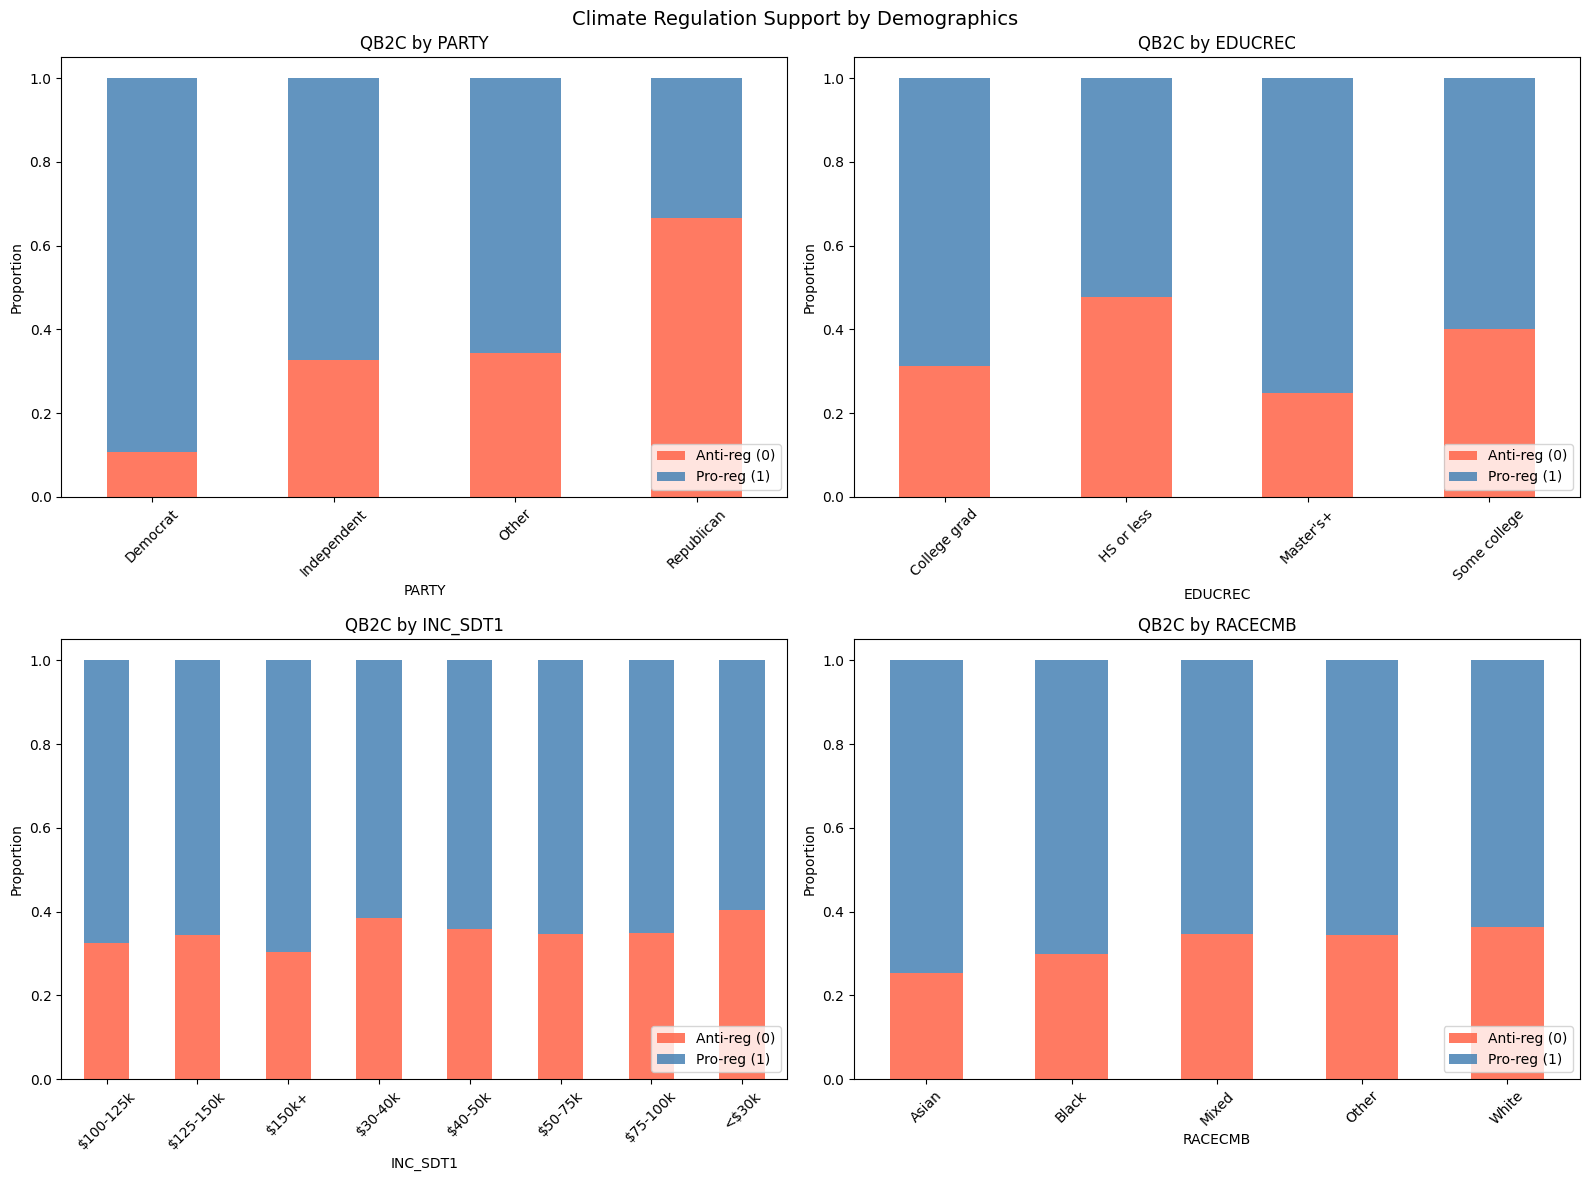

In [11]:
# QB2C vs Demographics cross-tabs
party_labels    = {1:'Republican', 2:'Democrat', 3:'Independent', 4:'Other'}
educrec_labels  = {1:'HS or less', 2:'Some college', 3:'College grad', 4:"Master's+"}
income_labels   = {1:'<$30k', 2:'$30-40k', 3:'$40-50k', 4:'$50-75k',
                   5:'$75-100k', 6:'$100-125k', 7:'$125-150k', 8:'$150k+'}
race_labels     = {1:'White', 2:'Black', 3:'Asian', 4:'Mixed', 5:'Other'}

demo_labels = {
    'PARTY':    party_labels,
    'EDUCREC':  educrec_labels,
    'INC_SDT1': income_labels,
    'RACECMB':  race_labels
}

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, (var, labels) in enumerate(demo_labels.items()):
    temp = df_binary[~df_binary[var].isin([99, 9])].copy()
    temp[var] = temp[var].map(labels)
    ct = pd.crosstab(temp[var], temp['QB2C_binary'], normalize='index')
    ct.columns = ['Anti-reg (0)', 'Pro-reg (1)']
    ct.plot(kind='bar', stacked=True, ax=axes[i],
            color=['tomato', 'steelblue'], alpha=0.85)
    axes[i].set_title(f'QB2C by {var}')
    axes[i].set_ylabel('Proportion')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].legend(loc='lower right')

plt.suptitle('Climate Regulation Support by Demographics', fontsize=14)
plt.tight_layout()
plt.savefig('../results/01_QB2C_By_Demographics.svg', bbox_inches='tight')
plt.show()